# NASA C-MAPSS FD001 — Gradient Boosting for RUL Prediction

**Author:** Pallavi 

---

## Objective

In this notebook, I will investigate whether Gradient Boosting can improve the RUL prediction performance achieved by the previous models.

Gradient Boosting builds trees sequentially, where each new tree focuses on reducing the errors made by the previous trees.

The current Linear Regression benchmark is:

- MAE: 25.16 cycles
- RMSE: 31.66 cycles
- R²: 0.768

I will use these results as the benchmark and evaluate Gradient Boosting on the same validation engines.

In [1]:
# Importing required libraries

import sys
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sys.path.append("../")

from src.preprocessing import load_training_data, remove_constant_features

In [2]:
# Loading and preparing the training data

train_df = load_training_data("../data/raw/train_FD001.txt")

train_df, constant_columns = remove_constant_features(train_df)

train_df.head()

,unit_id,cycle,setting_1,setting_2,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,191
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,190
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,189
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,187


In [3]:
# Creating the same training and validation split

import numpy as np

units = train_df["unit_id"].unique()

np.random.seed(42)
np.random.shuffle(units)

train_units = units[:80]
val_units = units[80:]

train_data = train_df[train_df["unit_id"].isin(train_units)]
val_data = train_df[train_df["unit_id"].isin(val_units)]

X_train = train_data.drop(columns=["unit_id", "RUL"])
y_train = train_data["RUL"]

X_val = val_data.drop(columns=["unit_id", "RUL"])
y_val = val_data["RUL"]

print("Training engines:", train_data["unit_id"].nunique())
print("Validation engines:", val_data["unit_id"].nunique())

Training engines: 80
Validation engines: 20


## Training and Evaluating Gradient Boosting

Gradient Boosting builds trees sequentially, with each new tree trying to correct the errors made by previous trees.

I will first train a baseline Gradient Boosting model and compare its validation performance with the current Linear Regression benchmark.

In [4]:
# Training and evaluating Gradient Boosting

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_val)

gb_mae = mean_absolute_error(y_val, gb_pred)
gb_rmse = mean_squared_error(y_val, gb_pred) ** 0.5
gb_r2 = r2_score(y_val, gb_pred)

print(f"MAE : {gb_mae:.2f} cycles")
print(f"RMSE: {gb_rmse:.2f} cycles")
print(f"R²  : {gb_r2:.3f}")

MAE : 27.76 cycles
RMSE: 38.91 cycles
R²  : 0.707


In [6]:
# Testing a few Gradient Boosting configurations

gb_configs = {
    "GB_200": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "GB_300": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "GB_depth2": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=2,
        random_state=42
    )
}

gb_results = []

for name, model in gb_configs.items():
    model.fit(X_train, y_train)

    pred = model.predict(X_val)

    mae = mean_absolute_error(y_val, pred)
    rmse = mean_squared_error(y_val, pred) ** 0.5
    r2 = r2_score(y_val, pred)

    gb_results.append([name, mae, rmse, r2])

gb_results_df = pd.DataFrame(
    gb_results,
    columns=["Model", "MAE", "RMSE", "R2"]
)

gb_results_df

,Model,MAE,RMSE,R2
0,GB_200,27.763855,38.914618,0.706650
1,GB_300,27.789954,38.970481,0.705807
2,GB_depth2,27.840626,38.901625,0.706846


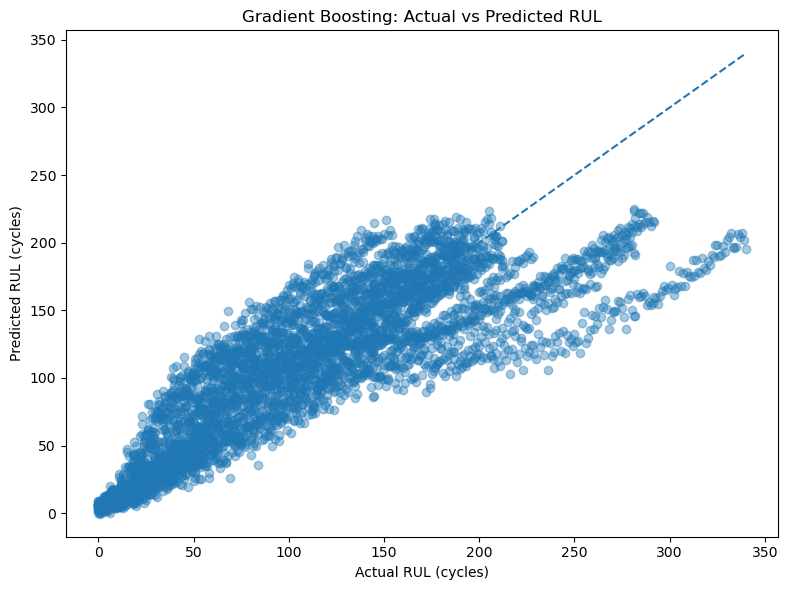

In [7]:
# Actual vs predicted RUL

plt.figure(figsize=(8, 6))

plt.scatter(y_val, gb_pred, alpha=0.4)

plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    linestyle="--"
)

plt.xlabel("Actual RUL (cycles)")
plt.ylabel("Predicted RUL (cycles)")
plt.title("Gradient Boosting: Actual vs Predicted RUL")

plt.tight_layout()

plt.savefig(
    "../reports/figures/gradient_boosting_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [8]:
# Final model comparison

final_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        25.16,
        27.87,
        gb_mae
    ],
    "RMSE": [
        31.66,
        39.34,
        gb_rmse
    ],
    "R2": [
        0.768,
        0.700,
        gb_r2
    ]
})

final_comparison

,Model,MAE,RMSE,R2
0,Linear Regression,25.160000,31.660000,0.76800
1,Random Forest,27.870000,39.340000,0.70000
2,Gradient Boosting,27.763855,38.914618,0.70665


## Final Findings

Gradient Boosting was tested as a nonlinear alternative to the Linear Regression baseline.

Gradient Boosting achieved an MAE of 27.76 cycles, RMSE of 38.91 cycles, and R² of 0.707. It performed slightly better than the tuned Random Forest model, but it remained worse than the Linear Regression baseline.

Therefore, Gradient Boosting did not provide a meaningful improvement for the current validation setup.

The Linear Regression model remains the best-performing model with an MAE of 25.16 cycles, RMSE of 31.66 cycles, and R² of 0.768.

The experiments suggest that increasing model complexity does not necessarily improve RUL prediction for this dataset.